# RANDOM WALK WITH OBSTACLES - MAZE
---

So far, our drunk man has wandered freely, at first in 1D, then in 2D. The only boundaries were the ditches we placed far away. But real environments have obstacles. Houses have furnitures. Streets have buildings. Forests have trees. Chips have circuit patterns.

In this notebook, we trap the drunk man inside a **grid maze**. He can only move through open cells. The question we try to answer is given enough random steps, how long it takes to find the exit. 

## 1. The Empty Maze — Drawing the Battlefield
---

Before the walker enters, we need a map. A 7×7 grid. Start at the top-left corner `(0,0)`. Exit at the bottom-right `(6,6)`. Black squares are walls — cells the walker cannot step on.

The walls are placed to create bottlenecks and dead ends. The walker has no knowledge of the layout. He walks randomly, we plot the static maze first.

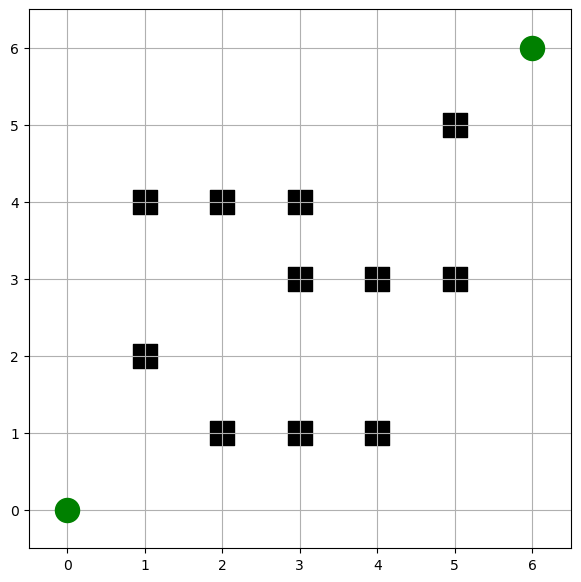

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.xticks(range(7))
plt.yticks(range(7))

plt.grid(True)

plt.xlim(-0.5, 6.5)
plt.ylim(-0.5, 6.5)

plt.scatter(0,0, color='green', s=300, zorder=5)
plt.scatter(6,6, color='green', s=300, zorder=5)

walls = [(2,1), (3,1), (4,1), (1,2), (3,3), (4,3), (5,3),
         (1,4), (2,4), (3,4), (5,5)]

for (wx, wy) in walls:
    plt.scatter(wx, wy, color='black', s=300, marker='s')
    
plt.show()

## 2. Building the Walker:
---

A walker starts at `(0,0)`. Each step:

1. Pick a random direction — up, down, left, or right
2. Calculate where that step would lead
3. Ask three questions before moving:
   - Is the new cell inside the grid?
   - Is it NOT a wall?
   - Is it the exit?

If the move is valid, he steps forward. If it's a wall or boundary, he stays put. If it's the exit, he escapes and the simulation stops.

We track his path as a blue line snaking through the maze. Sometimes he finds the exit quickly. Sometimes he wanders in circles for thousands of steps. 

Out


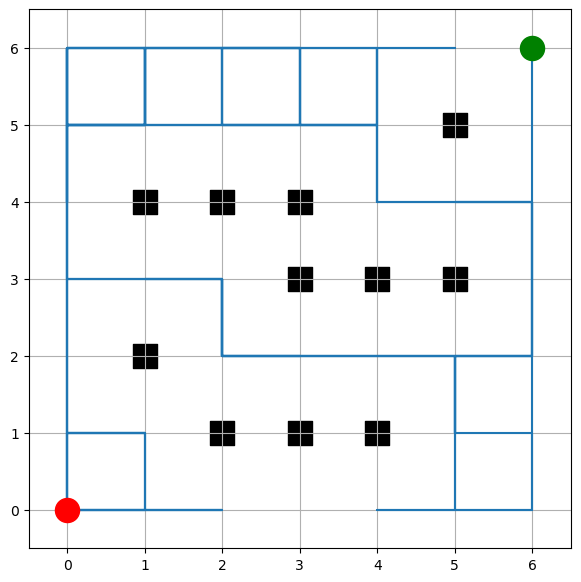

In [7]:
import random

n=5000
x_mov=[0]
y_mov=[0]
x=y=0
for _ in range (n):
    dx,dy=random.choice([(0,1),(0,-1),(1,0),(-1,0)])
    nx,ny=x+dx,y+dy
    
    if ((nx>=0 and nx<=6) and (ny>=0 and ny<=6) and (nx,ny) not in walls):
        x,y=nx,ny
        x_mov.append(nx)
        y_mov.append(ny)
        
    if (nx==6 and ny==6):
        print("Out")
        x_mov.append(nx)
        y_mov.append(ny)
        break


plt.figure(figsize=(7,7))

plt.xticks(range(7))
plt.yticks(range(7))

plt.grid(True)

plt.xlim(-0.5, 6.5)
plt.ylim(-0.5, 6.5)

plt.scatter(0,0, color='red', s=300, zorder=5)
plt.scatter(6,6, color='green', s=300, zorder=5)

walls = [(2,1), (3,1), (4,1), (1,2), (3,3), (4,3), (5,3),
         (1,4), (2,4), (3,4), (5,5)]

for (wx, wy) in walls:
    plt.scatter(wx, wy, color='black', s=300, marker='s')
plt.plot(x_mov,y_mov, linestyle='-')
plt.show()

## 3. Multiple Runs of the Maze: 
__________________

From one run we can say that the walker can find its exit if it can solve the maze, but now we check what multiple numbers of walker would do if they are left inside the same maze.

For each run we ask the input for the number of walkers (or number of times the walker walks) and for how many steps it moves before its time is out and we record whether it escaped and how many steps it took.

In [8]:
n=int(input("Enter Number of Times: "))
steps= int(input("Enter number of steps: "))

out=0
stats= []
esc=False
for _ in range (n):
    x=y=i=0
    for i in range (steps):
        dx,dy=random.choice([(0,1),(0,-1),(1,0),(-1,0)])
        nx,ny=x+dx,y+dy
        
        if ((nx>=0 and nx<=6) and (ny>=0 and ny<=6) and (nx,ny) not in walls):
            x,y=nx,ny
            
        if (nx==6 and ny==6):
            esc=True
            break
            
    if esc:
        out+=1
        stats.append(i+1)
        esc= False
    else:
        stats.append(-1)
print("Out times : ", out)
print("Escape Times : ", [s for s in stats if s != -1])


Enter Number of Times:  200
Enter number of steps:  2000


Out times :  200
Escape Times :  [310, 892, 303, 556, 397, 236, 579, 62, 480, 97, 89, 118, 128, 704, 122, 117, 270, 144, 202, 103, 241, 350, 41, 264, 831, 360, 338, 286, 306, 222, 137, 229, 549, 363, 1377, 124, 233, 415, 136, 178, 403, 91, 559, 306, 320, 695, 231, 210, 340, 160, 445, 539, 819, 188, 114, 142, 372, 230, 125, 201, 728, 901, 248, 114, 246, 229, 287, 74, 259, 709, 866, 422, 213, 387, 216, 719, 277, 126, 224, 153, 154, 446, 163, 190, 155, 178, 280, 387, 565, 435, 522, 70, 442, 162, 128, 73, 239, 337, 251, 162, 558, 815, 394, 307, 60, 212, 945, 140, 456, 1376, 488, 351, 590, 432, 182, 425, 223, 162, 59, 171, 213, 158, 56, 227, 136, 187, 458, 91, 436, 509, 396, 693, 448, 231, 744, 392, 198, 205, 731, 549, 876, 391, 190, 1270, 241, 136, 76, 280, 1133, 439, 71, 658, 210, 123, 1582, 323, 55, 701, 158, 657, 89, 357, 50, 68, 383, 879, 478, 372, 204, 229, 299, 93, 518, 42, 124, 861, 1029, 205, 680, 248, 61, 83, 167, 393, 157, 290, 364, 492, 331, 143, 1108, 155, 140, 976, 140, 412, 6

**RESULT**

The following sets of data shows us that 200 runs of 2000 steps each, as we can see the output is that it eascapes 200 times that is always, and that shows that the maze is constant and solvable. But randomness has no memory it can loop forever.

## 4. Statistics:
---

Now we increase the number of walkers and give them a larger number of steps, and we try to simulate what a large number of people trying to solve the maze would be like and we calculate the following from the curves that we got:
- Average Escape time
- Median Escape Time
  
and we plot a histogram to view the amount of steps everyone neeeded to complete the runs.


Enter Number of Times:  2000
Enter number of steps:  2000


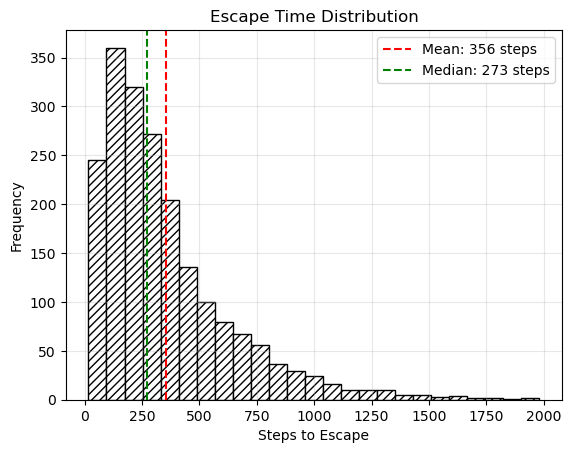

In [5]:
import random

n=int(input("Enter Number of Times: "))
steps= int(input("Enter number of steps: "))

out=0
stats= []
esc=False
for _ in range (n):
    x=y=i=0
    for i in range (steps):
        dx,dy=random.choice([(0,1),(0,-1),(1,0),(-1,0)])
        nx,ny=x+dx,y+dy
        
        if ((nx>=0 and nx<=6) and (ny>=0 and ny<=6) and (nx,ny) not in walls):
            x,y=nx,ny
            
        if (nx==6 and ny==6):
            esc=True
            break
            
    if esc:
        out+=1
        stats.append(i+1)
        esc= False
    else:
        stats.append(-1)

escape= [s for s in stats if s != -1]


plt.hist(escape, bins=25, color='white', hatch= '////', edgecolor='black')
plt.axvline(x=sum(escape)/len(escape), color='red', linestyle='--', label=f'Mean: {sum(escape)/len(escape):.0f} steps')
plt.xlabel("Steps to Escape")
plt.ylabel("Frequency")

escape_sort = sorted(escape)
median_val = escape_sort[len(escape) // 2]

plt.axvline(x=median_val, color='green', linestyle='--', label=f'Median: {median_val:.0f} steps')

plt.title(f'Escape Time Distribution')
plt.grid( True, alpha=0.3)
plt.legend()
plt.show()

**RESULT**

The plot tells that there is a gap between the median and mean, it shows that the data is skewed, and mode < median < mean shows that the data is positively skewed. The plot is evidence that the most escapes happens quickly but a long tail shows that the runs where the walker got trapped in dead-end corridoors. The mean is pulled far right of the peak by these outliers

## 5. Random Maze Generation:
---

Instead of a same static maze, let us build a maze generator, with a fixed number of walls (here 10) and then try to solve it. But to build that wall generator we need to remember the following things:
- A wall cannot be placed at the *START* and *END*
- Walls must not be duplicate

If we put in the following conditions to a random number generator for x and y coordinates we can make the wall generator.

Generated 10 walls in 12 attempts
Walls: [(2, 5), (6, 5), (5, 5), (4, 6), (1, 4), (4, 4), (6, 1), (3, 5), (3, 2), (6, 4)]


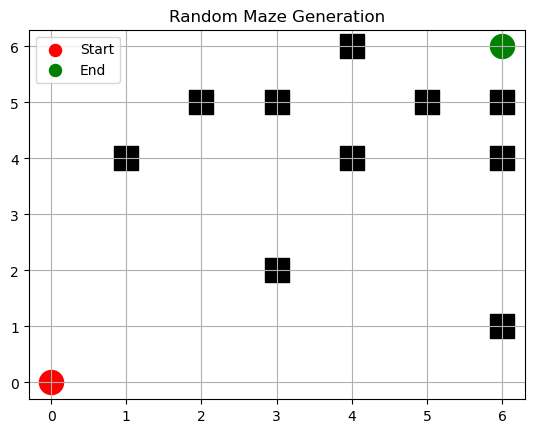

In [18]:
num_walls=10
walls=[]
attempts=0


while len(walls)<num_walls:
    wx=random.randint(0,6)
    wy=random.randint(0,6)
    attempts+=1
    if (wx,wy) not in [(0,0),(6,6)] and (wx,wy) not in walls:
        walls.append((wx,wy))

print(f"Generated {num_walls} walls in {attempts} attempts")
print(f"Walls: {walls}")

for wx,wy in walls:
    plt.scatter(wx,wy, s=300, marker='s', color='black')
plt.grid()
plt.scatter(0,0, s=300, marker='o', color='red', label='Start')
plt.scatter(6,6, s=300, marker='o', color='green', label='End')
plt.title("Random Maze Generation")
plt.legend(markerscale=0.5)
plt.show()

**RESULT**

The wall generator finally makes the maze itself, without requiring us to make the maze. (But there is a problem it cannot make sure always the maze is solvable)

## 6. Run walker on One Random Maze:
---

Now on that randomly generated maze, we try to make a walker walk through the entire maze in a given number of steps, and plot his path. 

Sometimes he escapes quickly if he finds spaces between walls, sometimes he doesnt, and at times he endlessly gets trapped in an unsolvable maze.  


Enter how many steps:  2000


Out
Escaped in 128 steps


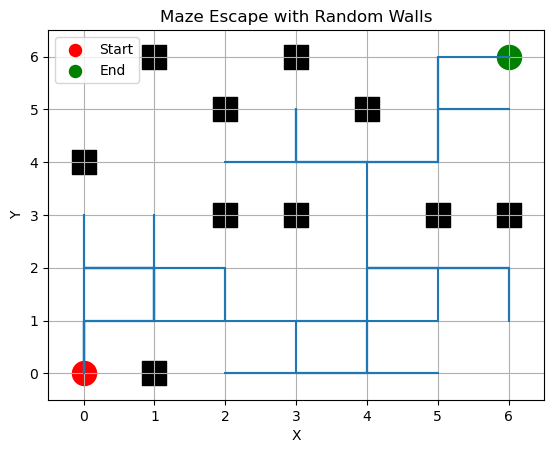

In [32]:


#wall generator:
def wall_gen():
    walls=[]
    while len(walls)<10:
        wx=random.randint(0,6)
        wy=random.randint(0,6)
        if (wx,wy) not in [(0,0),(6,6)] and (wx,wy) not in walls:
            walls.append((wx,wy))
    return walls

#walker:
def walker(n,walls):
    x_mov=[0]
    y_mov=[0]
    x=y=i=0
    esc= False
    
    for i in range (n):
        dx,dy=random.choice([(0,1),(0,-1),(1,0),(-1,0)])
        nx,ny=x+dx,y+dy

        if (nx==6 and ny==6):
            print("Out")
            x_mov.append(nx)
            y_mov.append(ny)
            esc=True
            break
            
        if ((nx>=0 and nx<=6) and (ny>=0 and ny<=6) and (nx,ny) not in walls):
            x,y=nx,ny
            x_mov.append(nx)
            y_mov.append(ny)
            

    steps = i + 1 if esc else -1
    return (steps,x_mov,y_mov)


n=int(input("Enter how many steps: "))
walls= wall_gen()
steps, x_mov, y_mov=walker(n, walls)

if steps==-1:
    print(f"Never Escaped")
else:
    print(f"Escaped in {steps} steps")

plt.plot(x_mov, y_mov)
for wx, wy in walls:
    plt.scatter(wx,wy, marker='s', color= 'black', s=300)

plt.scatter(0,0, marker='o', color='red', s=300 , label='Start')
plt.scatter(6,6, marker='o', color='green', s=300, label='End')
plt.xticks(range(7))
plt.yticks(range(7))
plt.xlim(-0.5, 6.5)
plt.ylim(-0.5, 6.5)
plt.legend(markerscale=0.5)
plt.title(f'Maze Escape with Random Walls')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid()
plt.show()



**RESULT:** 
He comes out of the maze in very short number of steps. And it was lucky to get a solvable maze, through which it can reach the exit. 

This shows us that the basic foundation part of our maze generator and walker is ready and we can further use this to check for multiple walkers and multiple mazes.

##  7. n random mazes with n random walkers:
---

Now we run the full experiment, for each of n mazes we generate a set of 10 random walls, and run one walker. Every maze is different and every walker is new. 

And after running the experiment we plot the histogram of all number of steps taken to find the exit. We also find the probability of escaping a random maze under the given number of steps.

Enter how many walkers and mazes:  5000
Enter how many steps per walker:  2000


Average Escape time 408.8435455086258 steps
Probability of Escaped Walkers: 0.8386


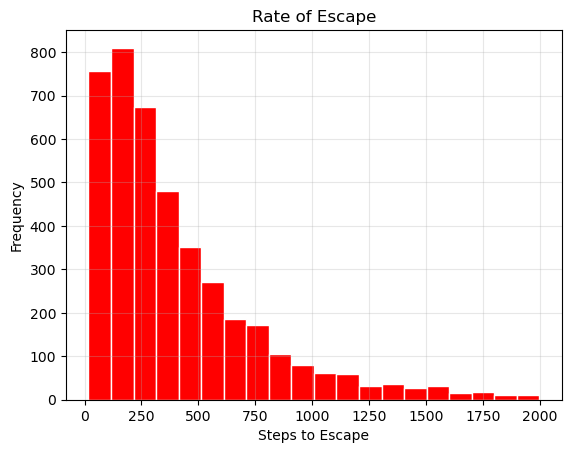

In [43]:

#wall generator:
def wall_gen():
    walls=[]
    while len(walls)<10:
        wx=random.randint(0,6)
        wy=random.randint(0,6)
        if (wx,wy) not in [(0,0),(6,6)] and (wx,wy) not in walls:
            walls.append((wx,wy))
    return walls

#walker:
def walker(step_in,walls):
    x=y=i=0
    esc= False
    
    for i in range (step_in):
        dx,dy=random.choice([(0,1),(0,-1),(1,0),(-1,0)])
        nx,ny=x+dx,y+dy

        if (nx==6 and ny==6):
            esc=True
            break
            
        if ((nx>=0 and nx<=6) and (ny>=0 and ny<=6) and (nx,ny) not in walls):
            x,y=nx,ny
            

    steps = i + 1 if esc else -1
    return (steps)


n=int(input("Enter how many walkers and mazes: "))
step_in=int(input("Enter how many steps per walker: "))
escaped=[]
for _ in range (n):
    walls= wall_gen()
    steps=walker(step_in, walls)
    if steps!=-1:
        escaped.append(steps)

step_avg= sum(escaped)/len(escaped)
print(f"Average Escape time {step_prob} steps")
prob= len(escaped)/n
print(f"Probability of Escaped Walkers: {prob}")
plt.hist(escaped, bins=20, color= 'red', edgecolor='white')
plt.title('Rate of Escape')
plt.xlabel('Steps to Escape')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()


The random maze distribution is nearly identical in shape to the fixed maze positively-skewed, with most escapes happening quickly and a long tail of difficult mazes where the walker got trapped. This suggests the escape time distribution is a property of random walks with constraints, not of any specific maze layout.

Some mazes are unsolvable, the walls block every path from start to exit. For these, no number of random steps will ever succeed. This is the limit of blind random walk: it cannot distinguish between 'difficult' and 'impossible.' 

## 8. Escape Probability vs Step Limit:
---

Let us check whether for the same maze the escape probability increases with the increase in the step limit, for each step limit we run 2000 walkers. As we know in real life, if we are given enough steps one day we might be able to solve the maze, we try that but also we know that blind walk can put a walker in an infinite loop so the probability even with infinite steps might not reach the value of 1 theoretically.

Steps allowed: 	 Probability
10 		 0.0
50 		 0.013
100 		 0.103
200 		 0.286
500 		 0.6855
1000 		 0.908
2000 		 0.9915
5000 		 1.0
10000 		 1.0


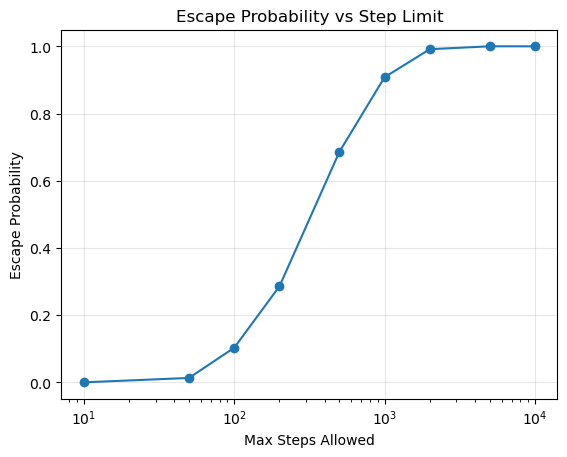

In [18]:
step_limits = [10, 50, 100, 200, 500, 1000, 2000, 5000, 10000]
probabilities = []


walls=[]
while len(walls)<10:
    wx=random.randint(0,6)
    wy=random.randint(0,6)
    if (wx,wy) not in [(0,0),(6,6)] and (wx,wy) not in walls:
        walls.append((wx,wy))



def walker(step_in):
    x=y=i=0
    esc= False
    
    for i in range (step_in):
        dx,dy=random.choice([(0,1),(0,-1),(1,0),(-1,0)])
        nx,ny=x+dx,y+dy

        if (nx==6 and ny==6):
            esc=True
            break
            
        if ((nx>=0 and nx<=6) and (ny>=0 and ny<=6) and (nx,ny) not in walls):
            x,y=nx,ny
            
    return (esc)


for limit in step_limits:
    escapes = 0
    for _ in range(2000):
        
        if walker(limit):
            escapes+=1
    
    probabilities.append(escapes / 2000)
print("Steps allowed: \t Probability")
for i in range (len(probabilities)):
    print(step_limits[i], "\t\t" , probabilities[i])
plt.plot(step_limits, probabilities, marker='o')
plt.xscale('log')
plt.xlabel('Max Steps Allowed')
plt.ylabel('Escape Probability')
plt.title('Escape Probability vs Step Limit')
plt.grid(True, alpha=0.3)
plt.show()

**RESULT** 

Probability rises quickly at first, then asymptotically approaches ~1. Here the 2000 steps gives a 99.15% escape rate which shows that the maze is easy so with around 10000 steps it easily flattens to 1. 

But the theoretical ceiling of an unsolvable maze would be zero, no matter the step limit. 

>The asymptote reveals the maze's difficulty: a hard maze asymptotes below 1; and an unsolvable maze asymptotes at 0

Therefore: Escape Probability $\propto$ Max Steps Allowed

## 9. Wall Density vs Escape Rate:
---

Now we keep the number of steps allowed constant and we vary the wall density and we take the the number of walkers to be 2000 (to keep things computable on my system). Theoretically the Escape Rate should decrease as the number of walls increases, as the Walls increase more and more path becomes restricted and at a time it might come down to it must have to take a set strict path to reach the end. Let us simulate the scenario and plot the outcome.

Enter number of steps allowed: 1000


Wall Density 	 Escape Rate
0 		 0.985
2 		 0.9825
4 		 0.9475
6 		 0.9255
8 		 0.848
10 		 0.7705
12 		 0.662
14 		 0.51
16 		 0.356
18 		 0.2155
20 		 0.1005


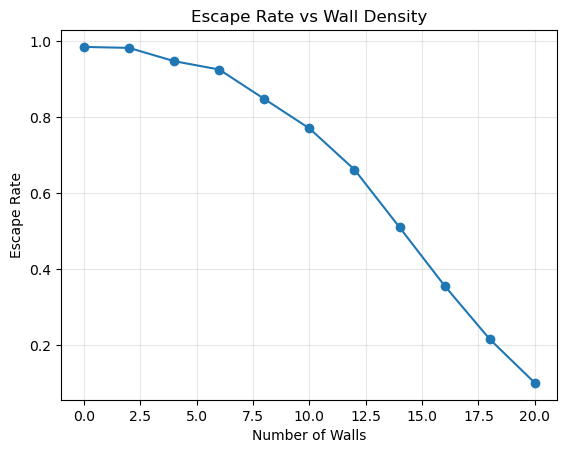

In [21]:
wall_counts = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
escape_rates = []

step_in=int(input("Enter number of steps allowed:"))

def wall_gen(n):
    walls=[]
    while len(walls)<n:
        wx=random.randint(0,6)
        wy=random.randint(0,6)
        if (wx,wy) not in [(0,0),(6,6)] and (wx,wy) not in walls:
            walls.append((wx,wy))
    return walls

def walker(step_in):
    x=y=i=0
    esc= False
    
    for i in range (step_in):
        dx,dy=random.choice([(0,1),(0,-1),(1,0),(-1,0)])
        nx,ny=x+dx,y+dy

        if (nx==6 and ny==6):
            esc=True
            break
            
        if ((nx>=0 and nx<=6) and (ny>=0 and ny<=6) and (nx,ny) not in walls):
            x,y=nx,ny
            
    return (esc)


for n in wall_counts:
    escapes = 0
    for _ in range(2000):
        walls = wall_gen(n)
        if walker(step_in):
            escapes+=1
        # if escaped: escapes += 1
    escape_rates.append(escapes / 2000)

print("Wall Density \t Escape Rate")
for i in range (len(wall_counts)):
    print(wall_counts[i], "\t\t" , escape_rates[i])
    
plt.plot(wall_counts, escape_rates, marker='o')
plt.xlabel('Number of Walls')
plt.ylabel('Escape Rate')
plt.title('Escape Rate vs Wall Density')
plt.grid(True, alpha=0.3)
plt.show()

**RESULT**

We have set maximum steps to be 1000, and the walls vary in sizes from 0 to 20. The escape rate drops steading as walls increase. At 0 walls nearly everyone (=98.5%) escapes and at 20 walls only 10% make it through. 

So we can say that:

$$\text{Escape Rate} \propto \frac{1}{\text{Number of Walls}}$$

## 10. Building a Always Solvable Maze:
---

We have seen an issue that sometimes the maze generator generates a maze that is impossible to solve, to counter that we build a maze generator that always generates solvable mazes. Let us begin by thinking this if a maze is to be solved there must be 2 points around a wall that connects, otherwise the wall will stop the person from going past through. To try and solve that I have tried a few methods but most of them keeps spawn-locking the walker (traps the walker in the start position), it will be revisited once I figure out the method. I have heard there are better and advanced methods to solve that but I am not able to do that right now, I will edit this or add it in a separate file under here.

## Conclusion — The Drunk Man in the Labyrinth
---

The drunk man from the previous segment has now learned to navigate a lot of different terrain. From open fields (1D) to city grids (2D), from circular ditches to walled mazes his stumbling has taught us how randomness and chaos can create and predict patterns. But every step he took was random. He never learned. He never remembered.


Here is a list of what we have built from random movement of a walker:

| Experiment | What It Taught Us |
|------------|-------------------|
| Fixed maze, single walker | Visualizing constrained random motion |
| Fixed maze, multiple walkers | Escape time is right-skewed — most quick, some endless |
| Random maze generator | Not all mazes are solvable |
| 2000 random mazes $\times$ 2000 walkers | Distribution is universal, not tied to one layout |
| Escape probability vs step limit | More steps help, but asymptote reveals maze difficulty |
| Escape rate vs wall density | Phase transition at ~14-16 walls |
| Always-solvable maze (attempted) | Edge cases are hard; revisit with better algorithms |



The random walker was never the problem. When a path exists, even a blind drunk man finds it, as we have seen that as the number of steps the walker gets increases, the probability of the maze being solved by a random person becomes solvable, regardless of wall count. The sharp drop in escape rate for random mazes was measuring **how often walls block all routes**, not how hard the maze is to solve.

Randomness is not weak. It's just blind. It cannot distinguish between "difficult" and "impossible."

### Limitations of our Current Approach:
---
- We gave the walker no memory. He revisits the same dead ends endlessly.
- We used no strategy, just used the basic random walk.
- We couldn't perfectly guarantee solvability without more advanced tools.

These limitations are not permanent. They're just waiting for better tools.
After I learn some better tools I'll return here and the drunk man will finally stop wandering in circles.

---